# Keras Squat Classifier — LSTM
Uses MediaPipe Pose to extract landmarks from video frames, then trains an LSTM
neural network on sequences of 20 consecutive frames.

Feeding sequences instead of single frames lets the model learn the *direction
of movement* — distinguishing between lowering into a squat and standing back up
even when the knee angle looks the same in both directions.

**Pipeline:**
1. MediaPipe extracts pose landmarks per frame
2. Only relevant landmarks + computed angles kept (24 features)
3. Frames grouped into sliding windows of 20; transition windows discarded
4. LSTM model trained on the sequences
5. Exported as `.keras`, `.tflite`, and `.onnx`

In [1]:
%pip install mediapipe opencv-python numpy tensorflow scikit-learn kagglehub tf2onnx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/839.1 kB ? eta -:--:--
   ---------------------------------------- 839.1/839.1 kB 7.1 MB/s  0:00:00
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/16.4 MB 9.7 MB/s eta 0:00:02
   ---------- ----------------------------- 4.2/16.4 MB 10.6 MB/s eta 0:00:02
   --------------- ------------------------ 6.6/16.4 MB 10.9 MB/s eta 0:00:01
   --------------------- ------------------ 8.9/16.4 MB 11.2 MB/s eta 0:00:01
   ---------------------------- ----------- 11.5/16.4 MB 11.4 MB/s eta 0:00:01
   --------------------------------- ------ 13.9/16.4 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------  16.3/16.4 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 11.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [onnx]
   ---------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\gusta\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 1 — Setup

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import os
import json
import shutil
import urllib.request
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

MODEL_PATH = os.path.join(os.getcwd(), 'pose_landmarker.task')

if not os.path.exists(MODEL_PATH):
    print('Downloading pose landmarker model...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task',
        MODEL_PATH
    )
    print('Done.')
else:
    print(f'Model found: {MODEL_PATH}')

SEQUENCE_LENGTH = 20

RELEVANT_IDX   = [11, 23, 24, 25, 26, 27, 28]
LEFT_SHOULDER  = 11
LEFT_HIP,  RIGHT_HIP   = 23, 24
LEFT_KNEE, RIGHT_KNEE  = 25, 26
LEFT_ANKLE,RIGHT_ANKLE = 27, 28

SQUAT_CONFIG = {
    'squat_knee_threshold':    120,
    'standing_knee_threshold': 150,
    'visibility_threshold':    0.6,
}

CLASS_NAMES = ['Standing (0)', 'Squat (1)']

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc  = a - b, c - b
    cosine  = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

def extract_features(landmarks):
    # Symmetric labeling: both squat and standing conditions use avg knee angle only.
    # Previous version had: squat = knee < 120 AND hip < 130 (asymmetric with standing).
    def get(idx):
        p = landmarks[idx]
        return [p.x, p.y], p.visibility

    sh_l, v1 = get(LEFT_SHOULDER)
    hi_l, v2 = get(LEFT_HIP)
    hi_r, v3 = get(RIGHT_HIP)
    kn_l, v4 = get(LEFT_KNEE)
    kn_r, v5 = get(RIGHT_KNEE)
    an_l, v6 = get(LEFT_ANKLE)
    an_r, v7 = get(RIGHT_ANKLE)

    if min(v1, v2, v3, v4, v5, v6, v7) < SQUAT_CONFIG['visibility_threshold']:
        return -1, None, None

    knee_l   = calculate_angle(hi_l, kn_l, an_l)
    knee_r   = calculate_angle(hi_r, kn_r, an_r)
    hip_l    = calculate_angle(sh_l, hi_l, kn_l)
    avg_knee = (knee_l + knee_r) / 2

    coords   = [v for idx in RELEVANT_IDX
                  for v in (landmarks[idx].x, landmarks[idx].y, landmarks[idx].visibility)]
    features = coords + [knee_l, knee_r, hip_l]   # 21 + 3 = 24

    if avg_knee < SQUAT_CONFIG['squat_knee_threshold']:
        label = 1
    elif avg_knee > SQUAT_CONFIG['standing_knee_threshold']:
        label = 0
    else:
        label = -1

    return label, features, avg_knee

FEATURE_SIZE = len(RELEVANT_IDX) * 3 + 3   # 24
print(f'Setup complete. Features per frame: {FEATURE_SIZE}, Sequence length: {SEQUENCE_LENGTH}')


## Step 2 — Download training videos from Kaggle

In [3]:
import kagglehub

VIDEOS_DIR = os.path.join(os.getcwd(), 'trainingData', 'videos')
os.makedirs(VIDEOS_DIR, exist_ok=True)

dataset_path = kagglehub.dataset_download('hasyimabdillah/workoutfitness-video')
print('Downloaded to:', dataset_path)

squat_folder = os.path.join(dataset_path, 'squat')
if not os.path.exists(squat_folder):
    for root, dirs, files in os.walk(dataset_path):
        if os.path.basename(root).lower() == 'squat':
            squat_folder = root
            break

print('Squat folder:', squat_folder)

for fname in os.listdir(squat_folder):
    if fname.endswith(('.mp4', '.mov', '.avi')):
        src = os.path.join(squat_folder, fname)
        dst = os.path.join(VIDEOS_DIR, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            print(f'Copied: {fname}')
        else:
            print(f'Already exists: {fname}')

print(f'\nTotal videos ready: {len(os.listdir(VIDEOS_DIR))}')

C:\Users\gusta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\gusta\.cache\kagglehub\datasets\hasyimabdillah\workoutfitness-video\versions\5
Squat folder: C:\Users\gusta\.cache\kagglehub\datasets\hasyimabdillah\workoutfitness-video\versions\5\squat
Already exists: squat_10.mp4
Already exists: squat_11.mp4
Already exists: squat_12.mp4
Already exists: squat_13.mp4
Already exists: squat_14.mp4
Already exists: squat_15.mp4
Already exists: squat_16.mp4
Already exists: squat_17.mp4
Already exists: squat_18.mp4
Already exists: squat_19.mp4
Already exists: squat_20.mp4
Already exists: squat_21.mp4
Already exists: squat_22.mp4
Already exists: squat_23.mp4
Already exists: squat_24.mp4
Already exists: squat_25.mp4
Already exists: squat_26.mp4
Already exists: squat_27.mp4
Already exists: squat_28.mp4
Already exists: squat_29.mp4
Already exists: squat_7.mp4
Already exists: squat_8.mp4
Already exists: squat_9.mp4

Total videos ready: 23


## Step 3 — Extract and auto-label frames

In [ ]:
VIDEO_PATHS = [
    os.path.join(VIDEOS_DIR, f)
    for f in os.listdir(VIDEOS_DIR)
    if f.endswith(('.mp4', '.mov', '.avi'))
]
print(f'Found {len(VIDEO_PATHS)} videos')

def process_video(video_path):
    # Uses the video's actual FPS for timestamps so MediaPipe timing is correct.
    raw = []
    cap = cv2.VideoCapture(video_path)
    total        = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
    ms_per_frame = 1000.0 / fps
    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
    )
    timestamp_ms = 0
    processed    = 0
    with mp_vision.PoseLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            timestamp_ms += int(ms_per_frame)
            rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result   = landmarker.detect_for_video(mp_image, timestamp_ms)
            if result.pose_landmarks:
                label, features, _ = extract_features(result.pose_landmarks[0])
                if label != -1 and features is not None:
                    raw.append((features, label))
                else:
                    raw.append(None)
            else:
                raw.append(None)
            processed += 1
            if processed % 100 == 0:
                print(f'  {processed}/{total} frames')
    cap.release()

    X, y = [], []
    for i in range(len(raw) - SEQUENCE_LENGTH + 1):
        window = raw[i:i + SEQUENCE_LENGTH]
        if None in window:
            continue
        feats  = [f for f, l in window]
        labels = [l for f, l in window]
        if len(set(labels)) == 1:
            X.append(feats)
            y.append(labels[-1])
    return X, y


# ── Feature-space augmentation ───────────────────────────────────────────────
# Squat feature layout (24 values per frame):
#   [0-2]   L_shoulder  (x, y, vis)
#   [3-5]   L_hip       (x, y, vis)
#   [6-8]   R_hip       (x, y, vis)
#   [9-11]  L_knee      (x, y, vis)
#   [12-14] R_knee      (x, y, vis)
#   [15-17] L_ankle     (x, y, vis)
#   [18-20] R_ankle     (x, y, vis)
#   [21]    knee_l angle
#   [22]    knee_r angle
#   [23]    hip_l angle
def mirror_squat_sequence(seq):
    mirrored = seq.copy()
    # L_shoulder (0-2) has no R counterpart — just flip its x
    mirrored[:, 0] = 1.0 - seq[:, 0]
    # swap paired triplets and flip x
    for lo, hi in [(3, 6), (9, 12), (15, 18)]:
        mirrored[:, lo]   = 1.0 - seq[:, hi]    # x
        mirrored[:, hi]   = 1.0 - seq[:, lo]    # x
        mirrored[:, lo+1] = seq[:, hi+1]         # y
        mirrored[:, hi+1] = seq[:, lo+1]         # y
        mirrored[:, lo+2] = seq[:, hi+2]         # vis
        mirrored[:, hi+2] = seq[:, lo+2]         # vis
    # swap L/R knee angles; hip_l stays as best approximation of hip_r
    mirrored[:, 21] = seq[:, 22]
    mirrored[:, 22] = seq[:, 21]
    return mirrored

def add_noise(seq, sigma=0.005):
    return seq + np.random.normal(0, sigma, seq.shape).astype(np.float32)

def augment(X, y, noise_copies=2):
    X_arr = np.array(X, dtype=np.float32)
    X_mir = np.array([mirror_squat_sequence(s) for s in X_arr])
    parts_X = [X_arr, X_mir] + [add_noise(X_arr) for _ in range(noise_copies)]
    parts_y = [y] * len(parts_X)
    return np.concatenate(parts_X), np.concatenate(parts_y)


X_all, y_all = [], []
for path in VIDEO_PATHS:
    print(f'Processing {os.path.basename(path)}...')
    Xv, yv = process_video(path)
    X_all.extend(Xv)
    y_all.extend(yv)

X_raw = np.array(X_all, dtype=np.float32)
y_raw = np.array(y_all, dtype=np.int32)
print(f'\nRaw sequences: {len(X_raw)} — standing: {np.sum(y_raw==0)}, squat: {np.sum(y_raw==1)}')

X, y = augment(X_raw, y_raw)
print(f'After augmentation: {len(X)} — standing: {np.sum(y==0)}, squat: {np.sum(y==1)}')
print(f'Input shape: {X.shape}')


## Step 4 — Train

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

N_tr, seq_len, n_feat = X_train.shape
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(N_tr, seq_len, n_feat)
X_val_s   = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_test_s  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)

INPUT_SIZE = n_feat

class_weights     = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')

model = keras.Sequential([
    keras.layers.Input(shape=(SEQUENCE_LENGTH, INPUT_SIZE)),
    keras.layers.LSTM(64),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid'),
])

optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'\nFinal held-out test accuracy: {acc:.4f}  |  loss: {loss:.4f}')

Train: 329  |  Val: 110  |  Test: 110
Class weights: {0: np.float64(0.9508670520231214), 1: np.float64(1.0544871794871795)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,897 (97.25 KB)

 Trainable params: 24,897 (97.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8723 - loss: 0.4692 - val_accuracy: 0.9818 - val_loss: 0.2386
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9757 - loss: 0.1798 - val_accuracy: 1.0000 - val_loss: 0.0827
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0686 - val_accuracy: 1.0000 - val_loss: 0.0287
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0301 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0199 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss

## Step 5 — Evaluate

=== Classification Report ===
              precision    recall  f1-score   support

Standing (0)       1.00      1.00      1.00        58
   Squat (1)       1.00      1.00      1.00        52

    accuracy                           1.00       110
   macro avg       1.00      1.00      1.00       110
weighted avg       1.00      1.00      1.00       110

=== Confusion Matrix ===
[[58  0]
 [ 0 52]]
Rows = actual class, Columns = predicted class


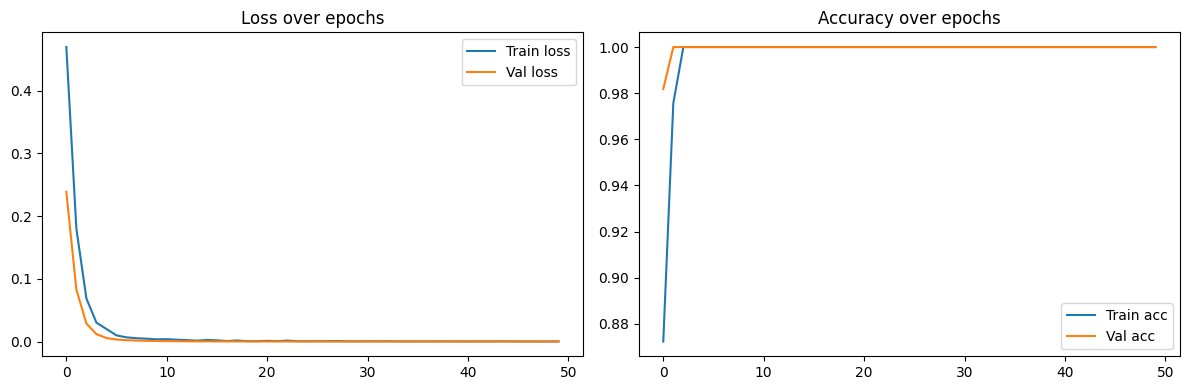

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_s, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

print('=== Confusion Matrix ===')
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Rows = actual class, Columns = predicted class')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train loss')
ax1.plot(history.history['val_loss'],     label='Val loss')
ax1.set_title('Loss over epochs'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train acc')
ax2.plot(history.history['val_accuracy'], label='Val acc')
ax2.set_title('Accuracy over epochs'); ax2.legend()
plt.tight_layout()
plt.show()

## Step 6 — Export

In [15]:
import tf2onnx, shutil

model.save('squat_model.keras')
print('Exported: squat_model.keras')

scaler_params = {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
with open('squat_model_scaler.json', 'w') as f:
    json.dump(scaler_params, f)
print('Exported: squat_model_scaler.json')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open('squat_model.tflite', 'wb') as f:
    f.write(tflite_model)
print('Exported: squat_model.tflite')

import subprocess, sys
model.export('onnx_tmp')
result = subprocess.run([
    sys.executable, '-m', 'tf2onnx.convert',
    '--saved-model', 'onnx_tmp',
    '--output', 'squat_model.onnx',
    '--opset', '13',
], capture_output=True, text=True)
shutil.rmtree('onnx_tmp')
if result.returncode != 0:
    print('ONNX error:', result.stderr)
else:
    print('Exported: squat_model.onnx')

Exported: squat_model.keras
Exported: squat_model_scaler.json
INFO:tensorflow:Assets written to: C:\Users\gusta\AppData\Local\Temp\tmpmp6wbrr8\assets


INFO:tensorflow:Assets written to: C:\Users\gusta\AppData\Local\Temp\tmpmp6wbrr8\assets


Saved artifact at 'C:\Users\gusta\AppData\Local\Temp\tmpmp6wbrr8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 24), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2017409606544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408564688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408583440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408581712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408582672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017407913424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408582096: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported: squat_model.tflite
INFO:tensorflow:Assets written to: onnx_tmp\assets


INFO:tensorflow:Assets written to: onnx_tmp\assets


Saved artifact at 'onnx_tmp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 24), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2017409606544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408564688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408583440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408581712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408582672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017407913424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2017408582096: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported: squat_model.onnx


## Step 7 — Live inference

In [ ]:
try:
    import tflite_runtime.interpreter as _tflite
    Interpreter = _tflite.Interpreter
except ImportError:
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter

from collections import deque

THRESHOLD    = 0.5
frame_buffer = deque(maxlen=SEQUENCE_LENGTH)

# TFLite interpreter — much faster than model.predict() in a live loop
tflite_interp = Interpreter(model_path='squat_model.tflite')
tflite_interp.allocate_tensors()
inp_details  = tflite_interp.get_input_details()
out_details  = tflite_interp.get_output_details()

def predict_tflite(seq_scaled):
    tflite_interp.set_tensor(inp_details[0]['index'],
                             seq_scaled[np.newaxis, ...].astype(np.float32))
    tflite_interp.invoke()
    return float(tflite_interp.get_tensor(out_details[0]['index'])[0][0])


base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.VIDEO,
)

cap          = cv2.VideoCapture(0)
squat_count  = 0
in_squat     = False
fps_live     = cap.get(cv2.CAP_PROP_FPS) or 30.0
ms_per_frame = 1000.0 / fps_live
timestamp_ms = 0

with mp_vision.PoseLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        timestamp_ms += int(ms_per_frame)
        rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result   = landmarker.detect_for_video(mp_image, timestamp_ms)

        if result.pose_landmarks:
            label, features, avg_knee = extract_features(result.pose_landmarks[0])
            if features is not None:
                frame_buffer.append(features)

            if len(frame_buffer) == SEQUENCE_LENGTH:
                seq        = np.array(list(frame_buffer), dtype=np.float32)
                seq_scaled = scaler.transform(seq)
                prob       = predict_tflite(seq_scaled)

                is_squat = prob > THRESHOLD
                if is_squat and not in_squat:
                    in_squat = True
                elif not is_squat and in_squat:
                    squat_count += 1
                    in_squat = False

                state = f'SQUAT {prob:.2f}' if is_squat else f'STANDING {1-prob:.2f}'
                color = (0, 255, 0) if is_squat else (0, 0, 255)
                knee_txt = f'  Knee:{avg_knee:.0f}' if avg_knee else ''
                cv2.putText(frame, f'{state}{knee_txt}  Reps:{squat_count}',
                            (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

        cv2.imshow('Squat Detector (LSTM)', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
